# 📊 Kredit Riski Analizi - Exploratory Data Analysis (EDA)

Bu notebook-da təmizlənmiş Kredit Risk datamızı vizual və statistik olaraq analiz edəcəyik. Hədəfimiz, hansı müştəri tiplərinin (yaş, gəlir, ev sahibliyi və s.) kredit ödənişlərində daha çox risk (Default) yaratdığını tapmaq və datanı SQL mərhələsi üçün hazırlamaqdır.

**Layihənin Məqsədi:** Bankın kredit riskini (`loan_status`) idarə etmək üçün datadakı daxili qanunauyğunluqları, ən kritik risk faktorlarını və müştəri seqmentlərinin Default (Kredit batma) dərəcələrini aşkar etmək.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Vizuallaşdırma parametrlərini minimalist və təmiz edirik
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Təmizlənmiş datanı yükləyirik
df = pd.read_csv('../data/cleaned/credit_risk_cleaned.csv')

print(f"Analiz üçün hazır olan data ölçüsü: {df.shape}")
df.head(3)

Analiz üçün hazır olan data ölçüsü: (32409, 13)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_emp_lenght
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,5.0
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,1.0
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,4.0


### 📊 Kritik Faktorların Korrelyasiya Analizi (Heatmap)
## 🔍  Kredit Risk Faktorlarının Korrelyasiya Analizi

Datanın ümumi riyazi strukturunu və hansı rəqəmsal faktorların kredit riskini (`loan_status`) 
artırıb-azaltdığını görmək üçün Korrelyasiya Matrisi hazırlanmışdır.
Analizin təmiz olması üçün əsas 7 rəqəmsal sütun seçilmişdir.

Datanın ümumi riyazi strukturunu anlamaq üçün hədəf dəyişənimiz (`loan_status`) 
və digər əsas rəqəmsal biznes metrikaları arasında Pearson Korrelyasiya Matrisi hesablanmışdır.
Bu analiz, hansı faktorların kredit riskini (Default) birbaşa təsirini və ya azaltdığını görməyə imkan verir.

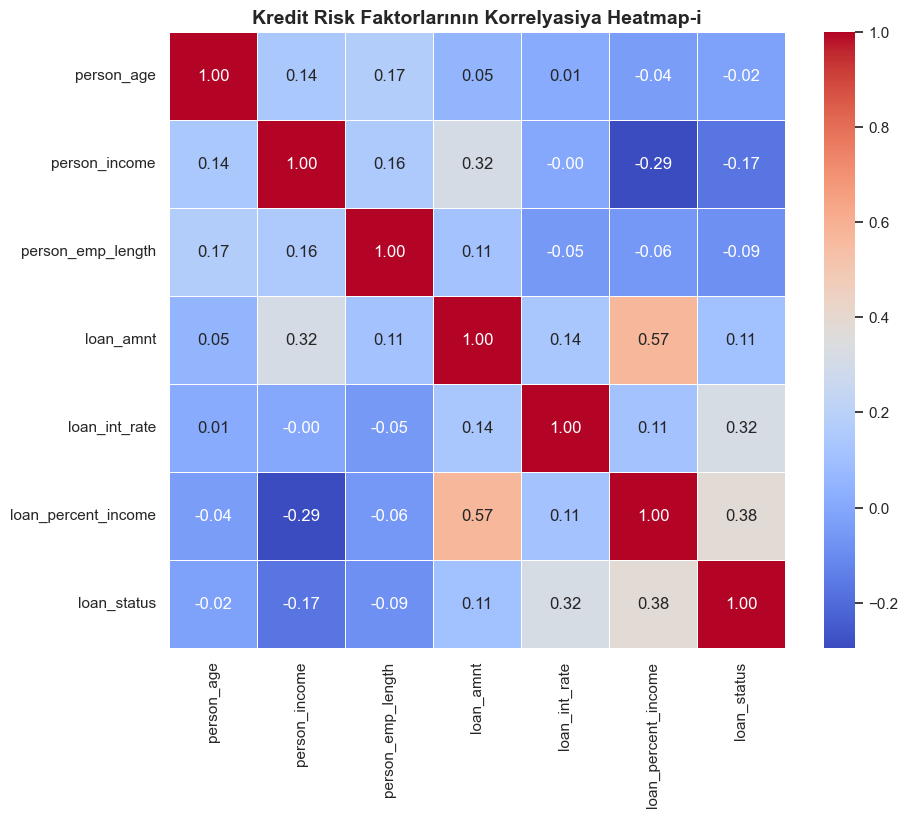

In [12]:
selected_columns = [
    'person_age',           # Müştərinin yaşı
    'person_income',        # İllik gəliri
    'person_emp_length',    # İş stajı (il)
    'loan_amnt',            # Kreditin məbləği
    'loan_int_rate',        # Kreditin faiz dərəcəsi
    'loan_percent_income',  # Kreditin gəlirə olan nisbəti
    'loan_status'           # Kreditin vəziyyəti (0 = Normal, 1 = Riskli)
]

corr_matrix = df[selected_columns].corr()

plt.figure(figsize=(10, 8))

# annot=True hər kəsişmənin içinə riyazi rəqəmi yazır
# cmap='coolwarm' mənfi əlaqələri göy, müsbətləri isə qırmızı rənglə göstərir
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True)

plt.title('Kredit Risk Faktorlarının Korrelyasiya Heatmap-i', fontsize=14, fontweight='bold')

plt.show()

#### 📌 Korrelyasiya Xəritəsindən Çıxan 5 Kritik Tapıntı:

Qrafikə əsasən, bankın risk menecmenti üçün ən mühüm tapıntılar və qərarlar aşağıdakılardır:
1. **🔴 Ən Böyük Risk: Borcun Gəlirə Nisbəti (`loan_percent_income` = 0.38)**
   * **Məntiq:** Kredit müştərinin illik gəlirinin nə qədər böyük hissəsini təşkil edirsə, risk bir o qədər artır.
   * **Qərar:** Gəlirinə görə çox böyük məbləğdə kredit istəyən şəxslərə ciddi limit qoyulmalıdır.


2. **🟠 Yüksək Kredit Faizi (`loan_int_rate` = 0.32)**
   * **Məntiq:** Faiz dərəcəsi yüksək olduqca aylıq ödəniş ağırlaşır və kreditin batma riski artır.
   * **Qərar:** Yüksək faizli kredit alan müştərilərdən əlavə zamin və ya girov tələb olunmalıdır.
     

3. **🟢 Riski Azaldan Faktor: İllik Gəlir (`person_income` = -0.17)**
   * **Məntiq:** Aralarında mənfi əlaqə var. Yəni, müştərinin illik gəliri artdıqca, kreditin batma riski azalır.
   * **Qərar:** Yüksək gəlirli müştərilərə kredit daha sürətli və asan şərtlərlə təsdiqlənməlidir.
     

4. **🔍 Güclü Əlaqə: Kredit Məbləği və Kredit Yükü (`loan_amnt` vs `loan_percent_income` = 0.57)**
   * **Məntiq:** Kreditin məbləği böyüdükcə, təbii olaraq onun müştərinin büdcəsinə saldığı faiz yükü də kəskin artır.
   * **Qərar:** Böyük məbləğli müraciətlərdə müştərinin təkcə maaşı yox, digər mülkləri də yoxlanmalıdır.
     

5. **📉 Gəlir və Kredit Yükünün Tərs Mütənasibliyi (`person_income` vs `loan_percent_income` = -0.29)**
   * **Məntiq:** İllik gəlir artdıqca, götürülən kreditin gəlirdəki payı avtomatik olaraq azalır və idarə edilməsi asanlaşır.
   * **Qərar:** Kredit limitləri təyin edilərkən müştərinin daxil olduğu gəlir seqmenti əsas götürülməlidir.

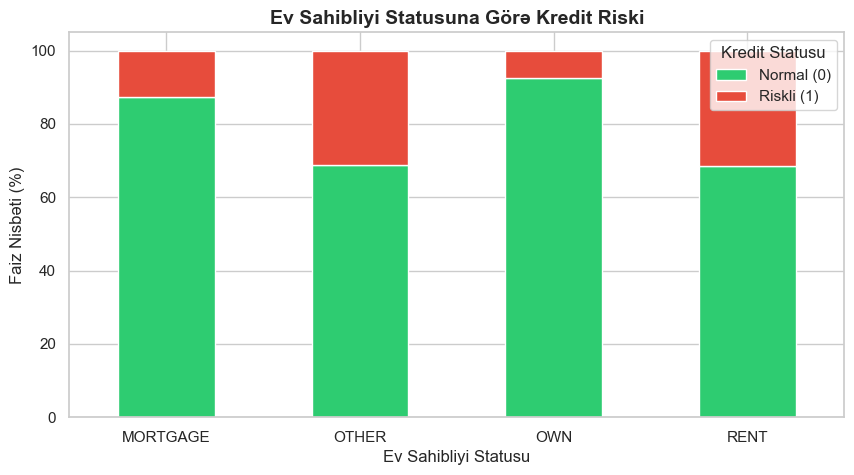

In [10]:
# Ev sahibliyinə görə kreditin batma riskini faizə çeviririk
home_risk = pd.crosstab(df['person_home_ownership'], df['loan_status'], normalize='index') * 100

# Qrafiki vizuallaşdırırıq (Yaşıl = Normal, Qırmızı = Riskli)
home_risk.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(10, 5))

plt.title('Ev Sahibliyi Statusuna Görə Kredit Riski', fontsize=14, fontweight='bold')
plt.xlabel('Ev Sahibliyi Statusu', fontsize=12)
plt.ylabel('Faiz Nisbəti (%)', fontsize=12)
plt.legend(title='Kredit Statusu', labels=['Normal (0)', 'Riskli (1)'])
plt.xticks(rotation=0)

plt.show()

#### 📌 Ev Sahibliyi Qrafikindən Çıxan Kritik Tapıntı:

* **Məntiq (Səbəb):** Kirayədə qalanların (`RENT`) və digər statusda olanların (`OTHER`) kredit batırma (riski) faizi təxminən 30%-ə yaxındır. Öz evi olanlarda (`OWN`) isə bu risk 10%-dən də aşağıdır. Ev sahibi olmaq müştərinin maliyyə sabitliyinin və məsuliyyətinin birbaşa göstəricisidir.
* **Biznes Qərarı:** Kredit şöbəsi kirayədə qalan (`RENT`) müştərilərə kredit ayırarkən daha ciddi anderraytinq (yoxlama) şərtləri tətbiq etməli, risk premiumunu fərqli hesablamalıdır.